In [ ]:
import logging
import os
import pickle
import random
import sys
from os.path import join

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

# from hyperopt import fmin, tpe, hp, Trials, rand
import xgboost as xgb
from sklearn import metrics
from sklearn.metrics import matthews_corrcoef, roc_auc_score
from sklearn.model_selection import KFold

sys.path.append("./additional_code")
# from data_preprocessing import *
CURRENT_DIR = os.getcwd()
print(CURRENT_DIR)
our_data = CURRENT_DIR + "/../data/our_data/"

/home/hanxd/Repositories/ESP/our_codes


In [ ]:
notrain_y_test_pred = np.load(join(our_data + "notrain_y_test_pred.npy"))
notrain_y_test = np.load(join(our_data + "notrain_y_test.npy"))

train0_y_test_pred = np.load(join(our_data + "train0_y_test_pred.npy"))
train0_y_test = np.load(join(our_data + "train0_y_test.npy"))
train1_y_test_pred = np.load(join(our_data + "train1_y_test_pred.npy"))
train1_y_test = np.load(join(our_data + "train1_y_test.npy"))
train2_y_test_pred = np.load(join(our_data + "train2_y_test_pred.npy"))
train2_y_test = np.load(join(our_data + "train2_y_test.npy"))
train3_y_test_pred = np.load(join(our_data + "train3_y_test_pred.npy"))
train3_y_test = np.load(join(our_data + "train3_y_test.npy"))
train4_y_test_pred = np.load(join(our_data + "train4_y_test_pred.npy"))
train4_y_test = np.load(join(our_data + "train4_y_test.npy"))


traincombined_y_test_pred = np.concatenate(
    [
        train0_y_test_pred,
        train1_y_test_pred,
        train2_y_test_pred,
        train3_y_test_pred,
        train4_y_test_pred,
    ],
    axis=0,
)
traincombined_y_test = np.concatenate(
    [train0_y_test, train1_y_test, train2_y_test, train3_y_test, train4_y_test], axis=0
)

In [ ]:
fpr_notrain, tpr_notrain, threshold = metrics.roc_curve(
    notrain_y_test, notrain_y_test_pred
)
roc_auc_notrain = metrics.auc(fpr_notrain, tpr_notrain)

fpr_train, tpr_train, threshold = metrics.roc_curve(
    traincombined_y_test, traincombined_y_test_pred
)
roc_auc_train = metrics.auc(fpr_train, tpr_train)

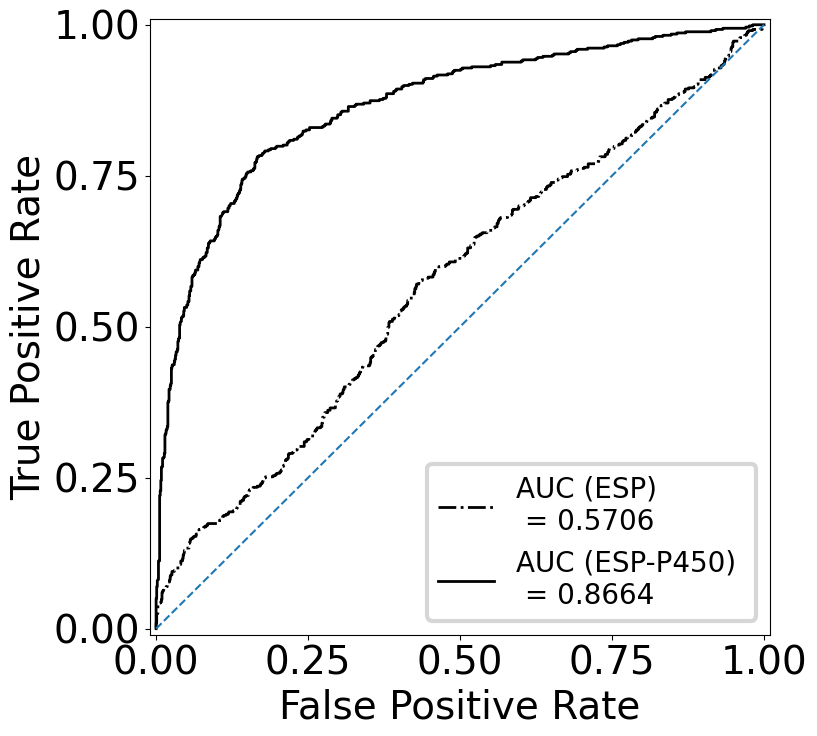

In [ ]:
fig, ax = plt.subplots(figsize=(8, 8))
plt.rcParams.update({"font.size": 28})


plt.plot(
    fpr_notrain,
    tpr_notrain,
    "black",
    linestyle="-.",
    label="AUC (ESP) \n = %0.4f" % roc_auc_notrain,
    linewidth=2.0,
)
plt.plot(
    fpr_train,
    tpr_train,
    "black",
    label="AUC (ESP-P450) \n = %0.4f" % roc_auc_train,
    linewidth=2.0,
)

ax.locator_params(axis="y", nbins=5)
ax.locator_params(axis="x", nbins=5)

leg = plt.legend(loc="lower right", fontsize=20, frameon=True)
leg.get_frame().set_linewidth(3.0)
plt.plot([0, 1], [0, 1], "--")
eps = 0.01
plt.xlim([0 - eps, 1 + eps])
plt.ylim([0 - eps, 1 + eps])
plt.ylabel("True Positive Rate")
plt.xlabel("False Positive Rate")
plt.show()

In [10]:
notrain_y_test_pred

array([0.04681509, 0.04799698, 0.31666026, ..., 0.2764789 , 0.05986103,
       0.4881832 ], dtype=float32)